# Ejercicio 3: Solar Flare

Tiempo de media energía tm = 1.656854
E(tm) = 0.500000


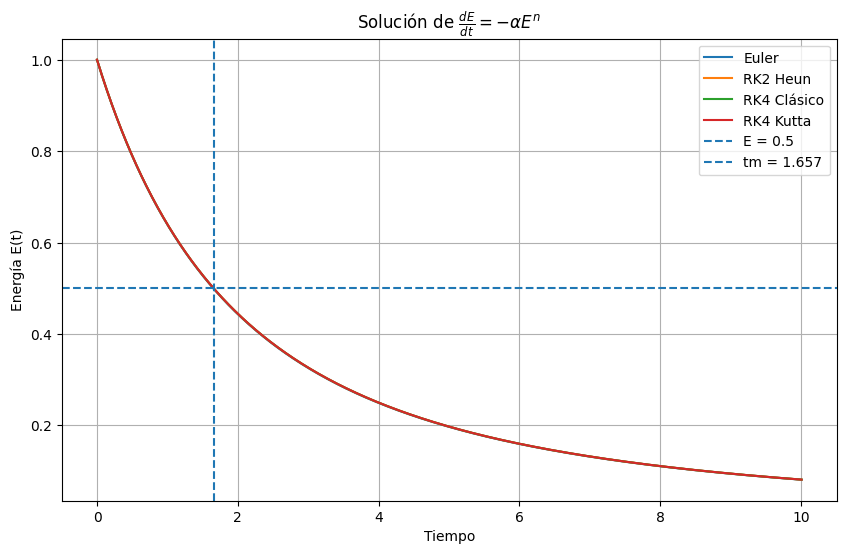

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Parámetros
alpha = 0.5
n = 1.5
E0 = 1.0
t0 = 0.0
tf = 10.0
h = 0.01

#EDO
def f(t, E):
    return -alpha * E**n

#Euler
def euler(f, t0, y0, h, tf):
    t = t0
    y = y0

    t_vals = [t]
    y_vals = [y]

    while t < tf:
        y = y + h * f(t, y)
        t += h

        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)

# RK2 - HEUN
def rk2_heun(f, t0, y0, h, tf):
    t = t0
    y = y0

    t_vals = [t]
    y_vals = [y]

    while t < tf:
        k1 = f(t, y)
        k2 = f(t + h, y + h * k1)

        y = y + (h / 2) * (k1 + k2)
        t += h

        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)

# RK4 CLÁSICO (RUNGE-KUTTA)
def rk4_runge(f, t0, y0, h, tf):
    t = t0
    y = y0

    t_vals = [t]
    y_vals = [y]

    while t < tf:
        k1 = f(t, y)
        k2 = f(t + h / 2, y + (h / 2) * k1)
        k3 = f(t + h / 2, y + (h / 2) * k2)
        k4 = f(t + h, y + h * k3)

        y = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t += h

        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)

# RK4 VARIANTE DE KUTTA
def rk4_kutta(f, t0, y0, h, tf):
    t = t0
    y = y0

    t_vals = [t]
    y_vals = [y]

    while t < tf:
        k1 = f(t, y)
        k2 = f(t + h / 3, y + (h / 3) * k1)
        k3 = f(t + 2 * h / 3, y - (h / 3) * k1 + h * k2)
        k4 = f(t + h, y + h * k1 - h * k2 + h * k3)

        y = y + (h / 8) * (k1 + 3 * k2 + 3 * k3 + k4)
        t += h

        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)

# SOL CON LOS 4 MÉTODOS
t_euler, E_euler = euler(f, t0, E0, h, tf)
t_heun, E_heun = rk2_heun(f, t0, E0, h, tf)
t_rk4, E_rk4 = rk4_runge(f, t0, E0, h, tf)
t_kutta, E_kutta = rk4_kutta(f, t0, E0, h, tf)

# FUNCIÓN E(t) CON RK4 CLÁSICO (para Newton-Raphson)
def E_of_t(t_target, h=0.01):
    t = 0.0
    E = E0

    while t < t_target:
        h_step = min(h, t_target - t)

        k1 = f(t, E)
        k2 = f(t + h_step / 2, E + (h_step / 2) * k1)
        k3 = f(t + h_step / 2, E + (h_step / 2) * k2)
        k4 = f(t + h_step, E + h_step * k3)

        E = E + (h_step / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t += h_step

    return E

# NEWTON-RAPHSON PARA E(t)=0.5
def newton_raphson(t0_guess=1.0, tol=1e-8, max_iter=100):
    t = t0_guess

    for _ in range(max_iter):
        F = E_of_t(t) - 0.5
        dF = f(t, E_of_t(t))   # dE/dt

        t_new = t - F / dF

        if abs(t_new - t) < tol:
            return t_new

        t = t_new

    return t


tm = newton_raphson()

print(f"Tiempo de media energía tm = {tm:.6f}")
print(f"E(tm) = {E_of_t(tm):.6f}")

# GRÁFICA FINAL
plt.figure(figsize=(10, 6))

plt.plot(t_euler, E_euler, label='Euler', linewidth=1.5)
plt.plot(t_heun, E_heun, label='RK2 Heun', linewidth=1.5)
plt.plot(t_rk4, E_rk4, label='RK4 Clásico', linewidth=1.5)
plt.plot(t_kutta, E_kutta, label='RK4 Kutta', linewidth=1.5)

plt.axhline(0.5, linestyle='--', label='E = 0.5')
plt.axvline(tm, linestyle='--', label=f'tm = {tm:.3f}')

plt.xlabel('Tiempo')
plt.ylabel('Energía E(t)')
plt.title(r'Solución de $\frac{dE}{dt}=-\alpha E^n$')
plt.grid(True)
plt.legend()
plt.show()

# Ejercicio de constantes: 

Usando las ecuaciones:

$$y_{i+1} = y_i + f(x_i, y_i)h + \frac{1}{2!}f'(x_i, y_i)h^2$$
$$y_{i+1} = y_i + (a_1 k_1 + a_2 k_2)h$$

Probar que las constantes $a_1, a_2, p_1$ y $q_{11}$ están dadas por las ecuaciones:

$$\begin{aligned} a_1 + a_2 &= 1 \\ a_2 p_1 &= \frac{1}{2} \\ a_2 q_{11} &= \frac{1}{2} \end{aligned}$$

Partimos de la expansión de Taylor de segundo orden para la solución exacta:
$$y_{i+1}=y_i+f(x_i,y_i)\,h+\frac{1}{2!}f'(x_i,y_i)\,h^2$$

Por otro lado, la forma general del método de Runge-Kutta de orden 2 es:
$$y_{i+1}=y_i+h(a_1k_1+a_2k_2)$$

donde se tiene: 
$$k_1=f(x_i,y_i)$$
$$k_2=f(x_i+p_1h,\;y_i+q_{11}hk_1)$$

## Expansión de $k_2$

Se expande $k_2$ mediante Taylor de primer orden alrededor del punto $(x_i,y_i)$:
$$k_2 \approx f(x_i,y_i)+\frac{\partial f}{\partial x}p_1h+\frac{\partial f}{\partial y}q_{11}hk_1$$

Como se tiene:
$$k_1=f(x_i,y_i)$$

Luego:
$$k_2 \approx f+p_1hf_x+q_{11}hf_yf$$

## Sustitución en RK2

Sustituyendo en la fórmula general:
$$y_{i+1}=y_i+h\left[a_1f+a_2\left(f+p_1hf_x+q_{11}hf_yf\right)\right]$$

Distribuyendo:
$$y_{i+1}=y_i+h(a_1+a_2)f+a_2p_1h^2f_x+a_2q_{11}h^2f_yf$$

## Expansión exacta de Taylor

Como se tiene: 
$$y'=f(x,y)$$
entonces:
$$y''=\frac{df}{dx}$$
Aplicando regla de la cadena:
$$y''=f_x+f_y y'$$
y como $y'=f$ se tiene entonces:
$$y''=f_x+f_yf$$
Por tanto, la expansión exacta queda:
$$y_{i+1}=y_i+hf+\frac{h^2}{2}(f_x+f_yf)$$
Expandiendo:
$$y_{i+1}=y_i+hf+\frac{h^2}{2}f_x+\frac{h^2}{2}f_yf$$

## Comparación término a término

Comparando ambas expresiones:

$$y_{i+1}=y_i+h(a_1+a_2)f+a_2p_1h^2f_x+a_2q_{11}h^2f_yf$$
y
$$y_{i+1}=y_i+hf+\frac{h^2}{2}f_x+\frac{h^2}{2}f_yf$$

se obtienen las condiciones:
$$a_1+a_2=1$$
$$a_2p_1=\frac{1}{2}$$
$$a_2q_{11}=\frac{1}{2}$$

## Resultado final

$$a_1+a_2=1$$
$$a_2p_1=\frac{1}{2}$$
$$a_2q_{11}=\frac{1}{2}$$

## Verificación para el método de Ralston

Para Ralston se toman:

$$
a_1=\frac{1}{3},\qquad
a_2=\frac{2}{3},\qquad
p_1=\frac{3}{4},\qquad
q_{11}=\frac{3}{4}
$$

Verificando:
$$\frac{1}{3}+\frac{2}{3}=1$$
$$\frac{2}{3}\cdot\frac{3}{4}=\frac{1}{2}$$
$$\frac{2}{3}\cdot\frac{3}{4}=\frac{1}{2}$$

Por lo tanto, el método de **Ralston satisface las condiciones de consistencia de RK2**.